In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, average_precision_score, precision_recall_curve
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

!pip install xgboost
from xgboost import XGBClassifier
import xgboost as xgb


from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, average_precision_score
from sklearn.model_selection import StratifiedKFold

!pip install shap

In [2]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\healthcare-dataset-stroke-data.csv")

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [5]:
df.shape

(5110, 12)

In [6]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [7]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [8]:
#check duplicates

df.duplicated().sum()

np.int64(0)

In [9]:
#check null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [10]:
#check sum of the null values

df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [11]:
#Stroke class distribution

df['stroke'].value_counts(normalize=True)

stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

### Data Understanding & Observations
- Data Size: 5,110 rows and 12 columns.
- Target Distribution: High imbalanced (4861 No Stroke, 249 Stroke).
- Missing Values: BMI has 201 missing valuess.
- Features: A mix of categorical (gender, work type, smoking status) and numerical (age, glucose, BMI) data.

### Data Cleaning & Pre-Processing

In [12]:
#drop 'id' column

df.drop('id', axis=1, inplace=True)

In [13]:
print(df.columns.tolist())

['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [14]:
#using Median imputation to fill bmi null values

median_bmi = df['bmi'].median()

df['bmi'] = df['bmi'].fillna(median_bmi)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [16]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Label Encoding Categorical columns

In [17]:
le = LabelEncoder()

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

### Scale Numerical Features

In [18]:
scaler = StandardScaler()

numerical_cols = ["age", "avg_glucose_level", "bmi"]

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

### Define X and y

In [19]:
X = df.drop('stroke', axis=1)
y = df['stroke']

In [20]:
X.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,1.051434,0,1,1,2,1,2.706375,1.005086,1
1,0,0.786070,0,0,1,3,0,2.121559,-0.098981,2
2,1,1.626390,0,1,1,2,0,-0.005028,0.472536,2
3,0,0.255342,0,0,1,2,1,1.437358,0.719327,3
4,0,1.582163,1,0,1,3,0,1.501184,-0.631531,2


In [21]:
y

0       1
1       1
2       1
3       1
4       1
       ..
5105    0
5106    0
5107    0
5108    0
5109    0
Name: stroke, Length: 5110, dtype: int64

### Summary
- Dropped id column as it provides no predictive value.
- BMI missing values were filled with the median (28.1) to handle outliers safely.
- Categorical columns (gender, ever_married, work_type, Residence_type, smoking_status) were label encoded.
- Numerical features (age, avg_glucose_level, bmi) were standardized using StandardScaler.
- Defined X and y

## Visualizations for Categorical features vs stroke

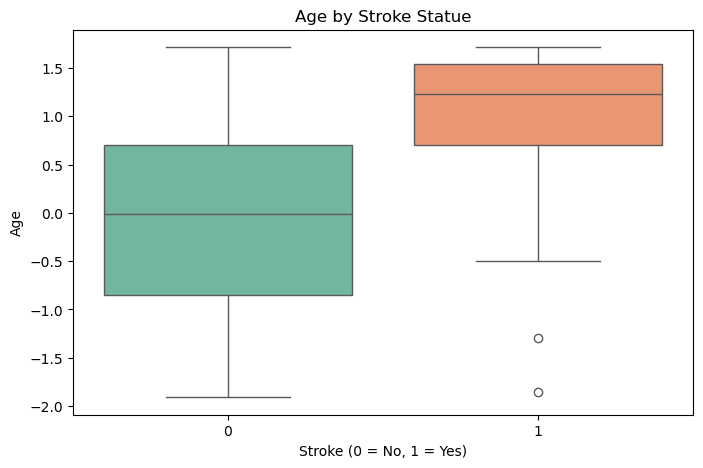

In [22]:
#Age vs Stroke

plt.figure(figsize=(8, 5))
sns.boxplot(x='stroke', y='age', data=df, palette='Set2', legend=False)
plt.title('Age by Stroke Statue')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

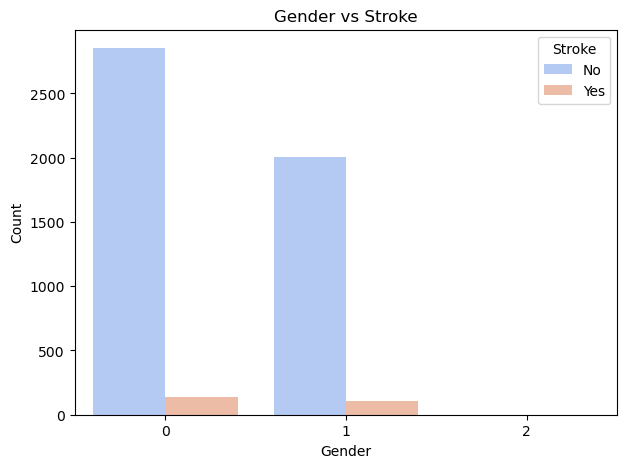

In [23]:
#Gender vs Stroke

plt.figure(figsize=(7, 5))
sns.countplot(x='gender', hue='stroke', data=df, palette='coolwarm')
plt.title('Gender vs Stroke')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Stroke', labels=['No', 'Yes'])
plt.show()

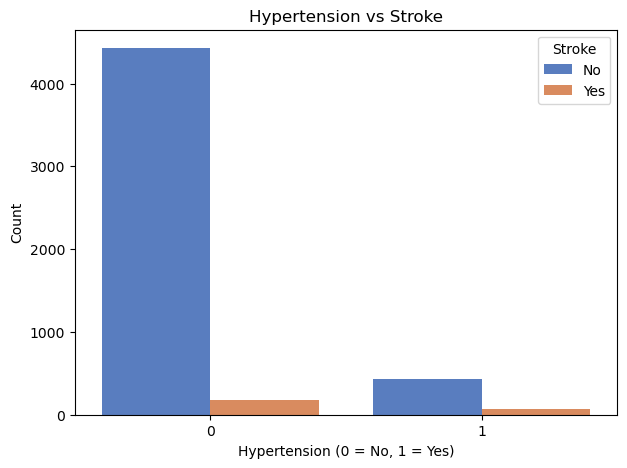

In [24]:
#Hypertension vs Stroke

plt.figure(figsize=(7, 5))
sns.countplot(x='hypertension', hue='stroke', data=df, palette='muted')
plt.title('Hypertension vs Stroke')
plt.xlabel('Hypertension (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Stroke', labels=['No', 'Yes'])
plt.show()

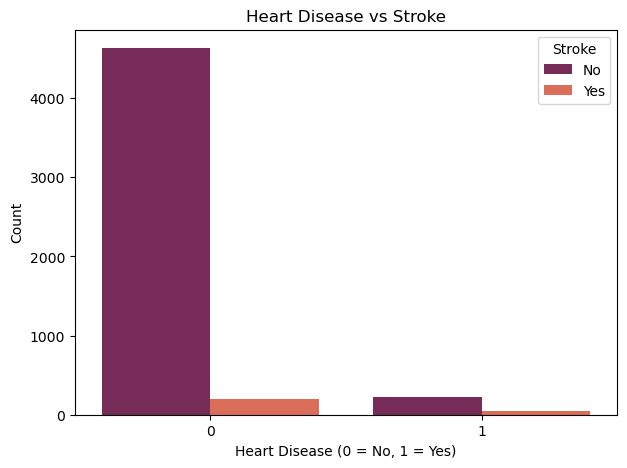

In [25]:
#Heart Disease vs Stroke

plt.figure(figsize=(7, 5))
sns.countplot(x='heart_disease', hue='stroke', data=df, palette='rocket')
plt.title('Heart Disease vs Stroke')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Stroke', labels=['No', 'Yes'])
plt.show()

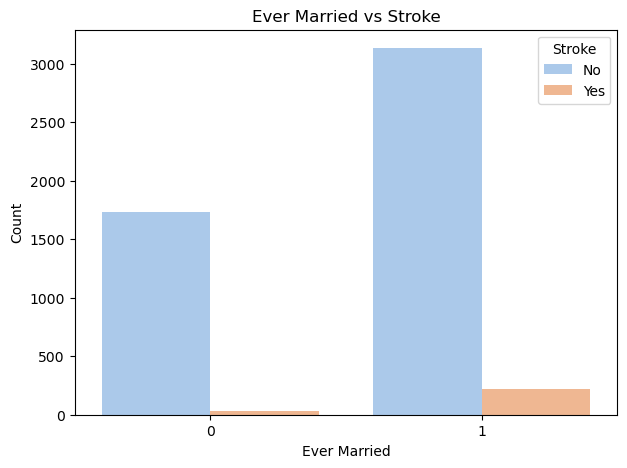

In [26]:
#Ever Married vs Stroke

plt.figure(figsize=(7, 5))
sns.countplot(x='ever_married', hue='stroke', data=df, palette='pastel')
plt.title('Ever Married vs Stroke')
plt.xlabel('Ever Married')
plt.ylabel('Count')
plt.legend(title='Stroke', labels=['No', 'Yes'])
plt.show()

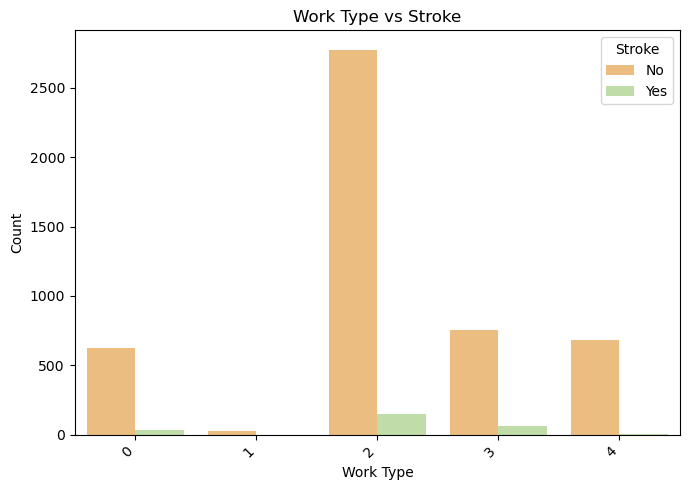

In [27]:
#Work Type vs Stroke

plt.figure(figsize=(7, 5))
sns.countplot(x='work_type', hue='stroke', data=df, palette='Spectral')
plt.title('Work Type vs Stroke')
plt.xlabel('Work Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stroke', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

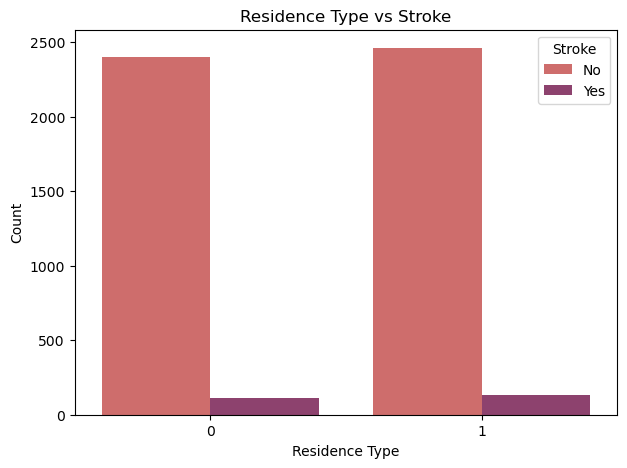

In [28]:
#Residence Type vs Stroke

plt.figure(figsize=(7, 5))
sns.countplot(x='Residence_type', hue='stroke', data=df, palette='flare')
plt.title('Residence Type vs Stroke')
plt.xlabel('Residence Type')
plt.ylabel('Count')
plt.legend(title='Stroke', labels=['No', 'Yes'])
plt.show()

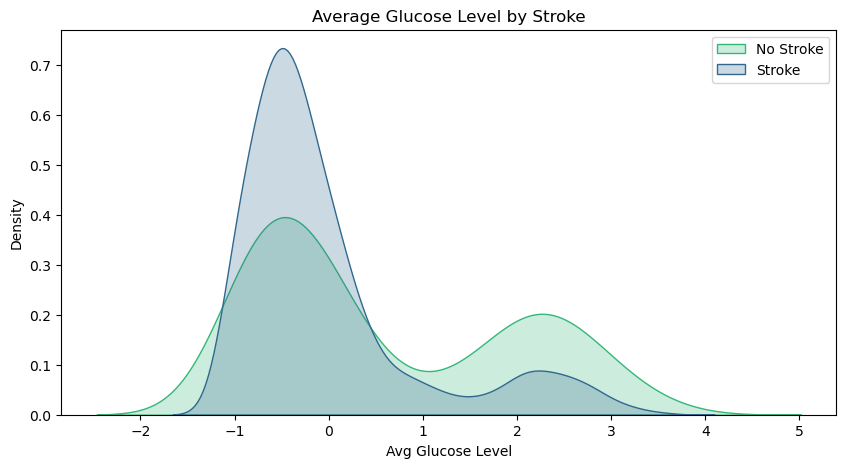

In [29]:
#Average Glucose Level vs Stroke

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='avg_glucose_level', hue='stroke', fill=True, common_norm=False, palette='viridis')
plt.title('Average Glucose Level by Stroke')
plt.xlabel('Avg Glucose Level')
plt.ylabel('Density')
plt.legend(labels=['No Stroke', 'Stroke'])
plt.show()

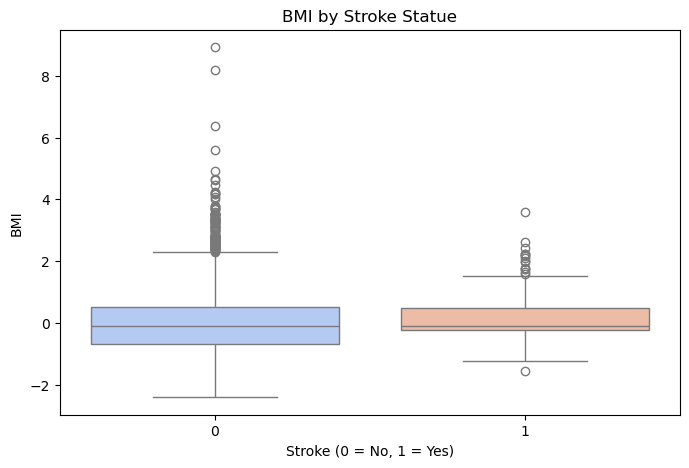

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='stroke', y='bmi', data=df, palette='coolwarm', legend=False)
plt.title('BMI by Stroke Statue')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('BMI')
plt.show()

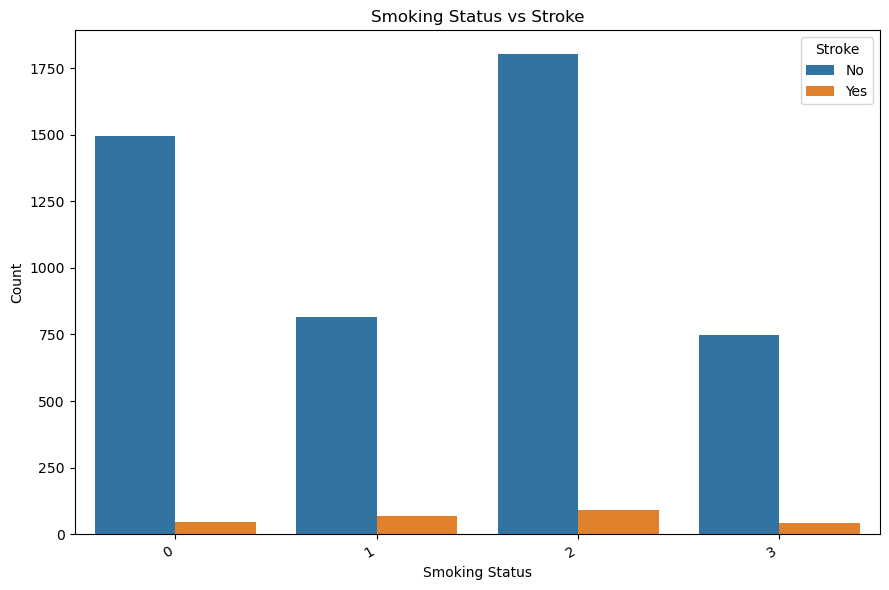

In [31]:
#Smoking Status vs Stroke

plt.figure(figsize=(9, 6))
sns.countplot(x='smoking_status', hue='stroke', data=df, palette='tab10')
plt.title('Smoking Status vs Stroke')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Stroke', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

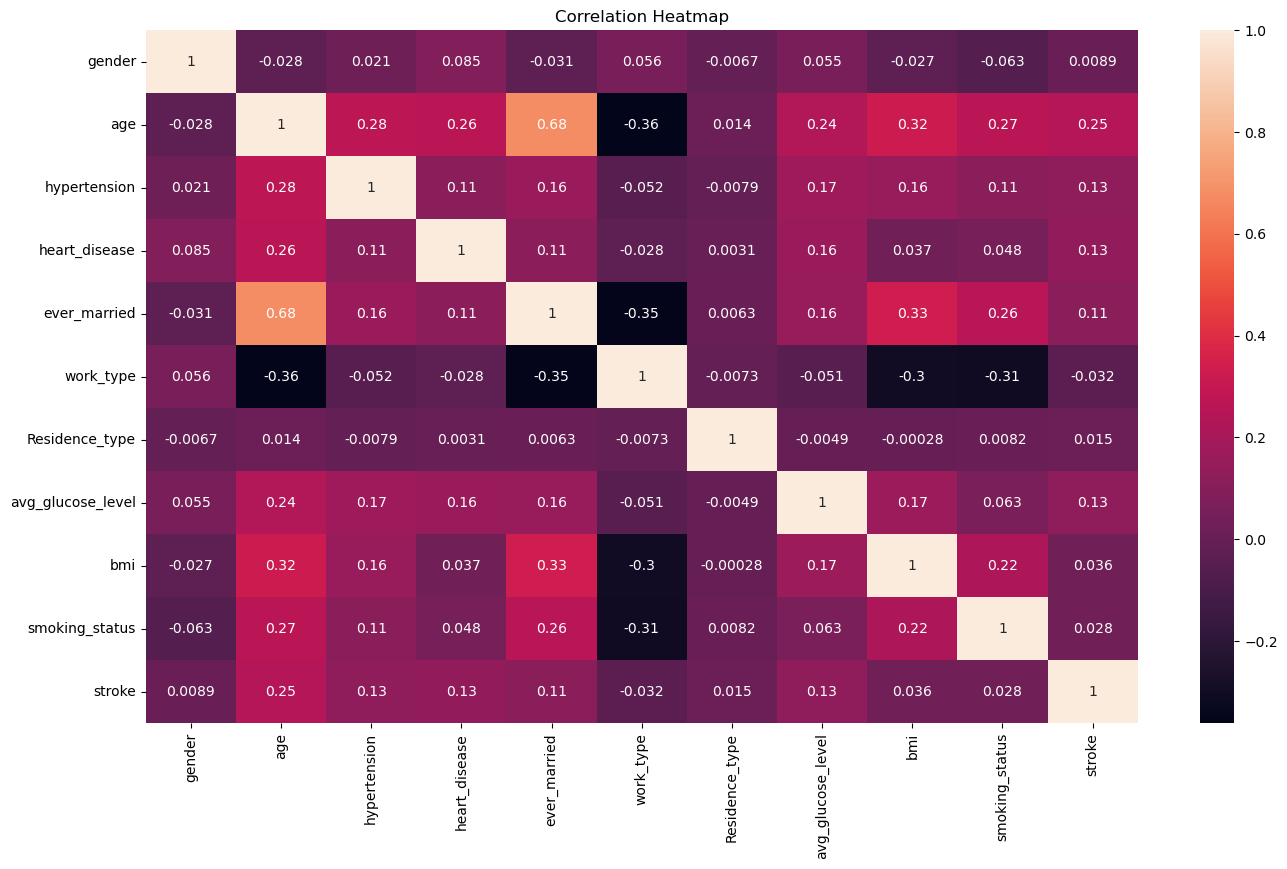

In [32]:
# to check how correlated the features are.
plt.figure(figsize=(16,9))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Key Insights from the visualizations
- Age: Stroke probability increases significantly with age
- Glucose: Higher average glucose levels appear correlated with higher stroke risk
- Class Imbalance: The vast majority of patients did not have a stroke, making the idenification of the few who did more challenging.

## Train-Test Split

In [33]:
#stratify because stroke is rare

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
X_train.shape

(4088, 10)

In [35]:
X_test.shape

(1022, 10)

In [36]:
y_train.shape

(4088,)

In [37]:
y_test.shape

(1022,)

In [38]:
y_train.value_counts(normalize=True)

stroke
0    0.951321
1    0.048679
Name: proportion, dtype: float64

In [39]:
y_test.value_counts(normalize=True)

stroke
0    0.951076
1    0.048924
Name: proportion, dtype: float64

### Summary
Performed a stratified train-test split on an imbalanced stroke (Apprpxmately 95% are negative cases while Approxmately 5% are positive cases), verified the shapes and confirmed that the class distribution remained consistent between train and test.

## Handling Class Imbalance

### Logistic Regression

In [40]:
#handle class imbalance using LogisticRegression with class_weight = 'balanced'

model = LogisticRegression(class_weight='balanced', random_state=42) #create model
model.fit(X_train, y_train) #Train model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Predict & Evaluate

In [41]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] #Probability of stroke = 1

In [42]:
print("ROC-AUC    :", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

ROC-AUC    : 0.8389094650205761

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.55      1022
weighted avg       0.95      0.75      0.82      1022


Confusion Matrix:

[[728 244]
 [ 10  40]]


### Interpretation and insights
- ROC-AUC $\approx 0.834$, decent seperation but not excellent for a medical task
- Recall for stroke (class 1) = 0.80. Good, it catch 80% of actual strokes (40 out of 50)
- Precision for stroke = 0.14. very low, lots of false positives (244 false alarms out of 284 predicted strokes)
- F1 for stroke = 0.24. low, because precision is dragged down heavily.
- Confusion matrix:
  [[728 244] 728 true negatives, 244 false positives
  [10 40]] 10 false negatives, 40 true positives

This is classic behavior on highly imbalanced data (~5% positive class): the model becomes aggressive on the minority class thanks to class_weight = 'balanced', which is good for recall, but hurts precision badly

In healthecare (stroke prediction):
High recall is usually more important than high precision (better to have some false alarm than miss real strokes).


### Threshold tuning on probabilities

In [43]:
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred_adj = (y_pred_proba >= thresh). astype(int)
    print(f"Threshold {thresh:.2f} Precision: {precision_score(y_test, y_pred_adj):.3f}, Recall: {recall_score(y_test, y_pred_adj):.3f}, F1: {f1_score(y_test, y_pred_adj):.3f}")

Threshold 0.10 Precision: 0.072, Recall: 0.960, F1: 0.133
Threshold 0.20 Precision: 0.081, Recall: 0.860, F1: 0.148
Threshold 0.30 Precision: 0.095, Recall: 0.840, F1: 0.171
Threshold 0.40 Precision: 0.117, Recall: 0.840, F1: 0.206
Threshold 0.50 Precision: 0.141, Recall: 0.800, F1: 0.240


### Interpretation
Threshold tuning didn't improve the F1 (from ~0.24 - ~0.241), its advisable to switch to tree-based gradient boosting models

### Why switching to tree-based boosting models?
- They naturally handle numerical/categorical features well
- Built in support for class imbalance via scale_pos_weight (XGBoost)
- Better at capturing non-linear interactions and rare-event patterns than logistic regression

## Train XGBoost with imbalance handling

In [44]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", pos_weight)

scale_pos_weight: 19.542713567839197


In [45]:
xgb = XGBClassifier(scale_pos_weight=pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_estimator=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1
                   )

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


### Predict & Evaluate

In [46]:
y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

In [47]:
print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_pred_proba_xgb):.4f}")

XGBoost Results:
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.13      0.82      0.23        50

    accuracy                           0.73      1022
   macro avg       0.56      0.77      0.53      1022
weighted avg       0.95      0.73      0.81      1022

ROC-AUC: 0.8559
PR-AUC: 0.2992


### Threshold Tuning on XGBoost Model

In [48]:
thresholds = np.arange(0.05, 0.51, 0.02)

print("Threshold | Precision | Recall | F1-score | Approx. Predicted Positive")
print("-" * 70)

results = []

for thresh in thresholds:
    y_pred_adj = (y_pred_proba_xgb >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_adj, zero_division=0)
    rec = recall_score(y_test, y_pred_adj, zero_division=0)
    f1 = f1_score(y_test, y_pred_adj, zero_division=0)
    pred_pos = y_pred_adj.sum()
    
    print(f"{thresh:.2f}    | {prec:.3f}    | {rec:.3f}    | {f1:.3f}    | {pred_pos}")
    results.append((thresh, prec, rec, f1))

Threshold | Precision | Recall | F1-score | Approx. Predicted Positive
----------------------------------------------------------------------
0.05    | 0.080    | 0.940    | 0.147    | 591
0.07    | 0.083    | 0.920    | 0.153    | 552
0.09    | 0.088    | 0.920    | 0.160    | 524
0.11    | 0.089    | 0.900    | 0.162    | 506
0.13    | 0.089    | 0.880    | 0.161    | 495
0.15    | 0.092    | 0.880    | 0.167    | 476
0.17    | 0.090    | 0.840    | 0.162    | 468
0.19    | 0.090    | 0.840    | 0.163    | 466
0.21    | 0.091    | 0.840    | 0.164    | 463
0.23    | 0.091    | 0.840    | 0.165    | 460
0.25    | 0.093    | 0.840    | 0.167    | 453
0.27    | 0.095    | 0.840    | 0.170    | 443
0.29    | 0.098    | 0.840    | 0.175    | 430
0.31    | 0.099    | 0.840    | 0.178    | 423
0.33    | 0.101    | 0.840    | 0.181    | 415
0.35    | 0.105    | 0.840    | 0.186    | 401
0.37    | 0.107    | 0.840    | 0.190    | 392
0.39    | 0.111    | 0.840    | 0.195    | 380
0.41    | 0.

In [49]:
best_idx = np.argmax([r[3] for r in results])
best_thresh, best_prec, best_rec, best_f1 = results[best_idx]

print("\n" + "="*60)
print(f"BEST THRESHOLD: {best_thresh:.3f}")
print(f"Precision: {best_prec:.3f} | Recall: {best_rec:.3f} | F1: {best_f1:.3f}")


BEST THRESHOLD: 0.490
Precision: 0.132 | Recall: 0.820 | F1: 0.227


## Restrain Final Model (Clean Version)

In [50]:
#final model with best parameters

final_model = XGBClassifier(scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='aucpr',
    random_state=42,
    n_estimator=300,
    learning_rate=0.05,
    max_depth=4
)

final_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


In [51]:
#Quick check on test set with chosen threshold

y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_pred_proba >= 0.49).astype(int)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.99      0.76      0.86       972
           1       0.15      0.82      0.26        50

    accuracy                           0.77      1022
   macro avg       0.57      0.79      0.56      1022
weighted avg       0.95      0.77      0.83      1022



### Feature Importance

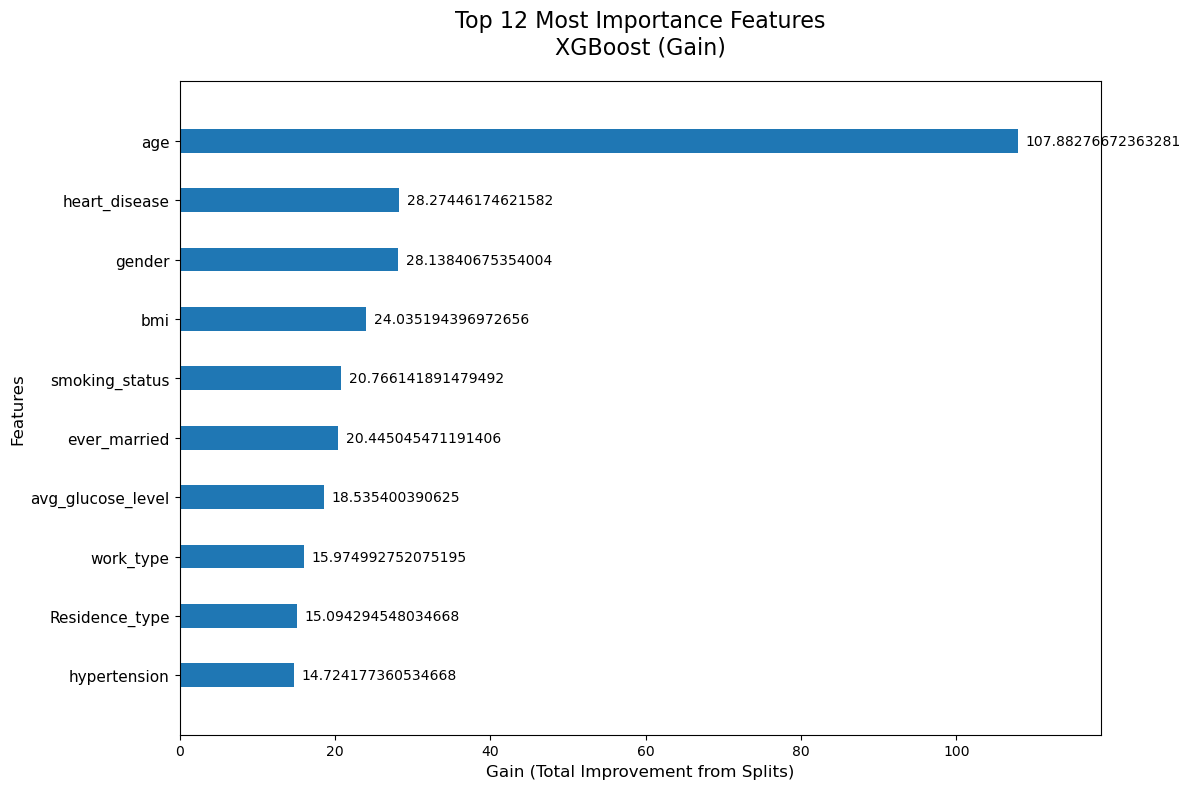

In [52]:
import xgboost as xgb

fig, ax = plt.subplots(figsize=(12, 8))
xgb.plot_importance(final_model,
                    ax=ax,
                    max_num_features=12,
                    importance_type='gain',
                    height=0.4,
                    show_values=True,
                    grid=False)

plt.title("Top 12 Most Importance Features\nXGBoost (Gain)", fontsize=16, pad=20)
plt.xlabel("Gain (Total Improvement from Splits)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.yticks(fontsize=11)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

### Intrepretation
This plot shows Features Importance by Gain, meaning how much each feature contributes to improving the model's splits and predictions.
Higher gain = more important feature.

### Key Takeaways
- Age dominates everything, this is normal and expected in stroke datasets.
- Traditional risk factors (heart diseases, bmi, smoking, glucose) are all appearing in the top rank, the model is learning medically meaningful patterns, not random noise. That's a good sign of model quality.
- Gender ranked so high (reflects real biological differences)
- Lower ranked features like hypertension and Residence type still contribute, but their individual impact is smaller.

### SHAP Explanation

In [53]:
import shap

#create explainer
explainer = shap.TreeExplainer(final_model)

#calculate SHAP values 
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")
print("Shape of shap_values:", shap_values.shape)


SHAP values calculated successfully!
Shape of shap_values: (1022, 10)


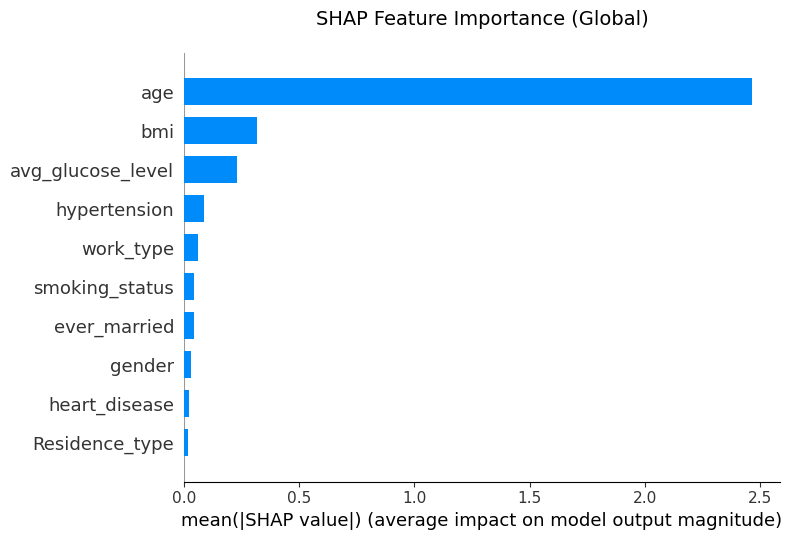

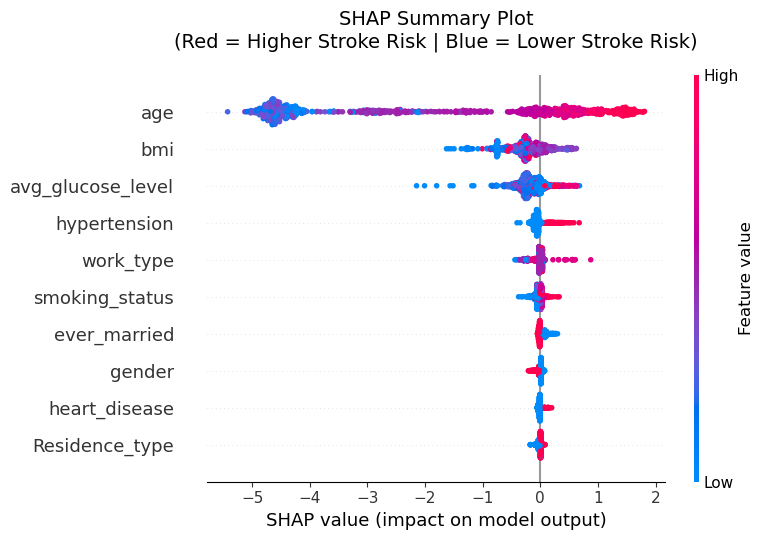

In [54]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10, show=False)
plt.title("SHAP Feature Importance (Global)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.title("SHAP Summary Plot\n(Red = Higher Stroke Risk | Blue = Lower Stroke Risk)",
          fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [57]:
import pickle

#model
with open("Stroke_prediction_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

In [58]:
#encoder
with open("Stroke_prediction_encoder.pkl", "wb") as file:
    pickle.dump(le, file)

#scaler
with open("Stroke_prediction_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)